In [26]:
# Install required packages for this notebook (kernel environment)
%pip install -q pandas numpy scikit-learn tensorflow matplotlib


Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\Ved\Desktop\ce6018\cleaned_data_updated.csv')

# Base columns
base_df = df[[
    "Earthquake_Magnitude",
    "Rjb_km",
    "Vs30_Selected_for_Analysis_m_s",
    "Fault_Type",
    "PGA_g"
]].rename(columns={
    "Earthquake_Magnitude": "M",
    "Rjb_km": "R",
    "Vs30_Selected_for_Analysis_m_s": "Vs30",
    "Fault_Type": "FM",
    "PGA_g": "PGA"
})

# Extra columns
extra_df = df[["PGA_g", "PGV_cm_sec"]].copy()

# SA columns
sa_columns = df.loc[:, "T0pt010S":"T4pt000S"].columns
sa_df = df[sa_columns].copy()

# Rename SA columns
def rename_sa(col):
    value = col.replace("T", "").replace("pt", ".").replace("S", "")
    value = float(value)
    return f"{value:.2f} sec"

sa_df.rename(columns={col: rename_sa(col) for col in sa_df.columns}, inplace=True)

# Combine
clean_df = pd.concat([base_df, extra_df, sa_df], axis=1)

# Remove zero/negative before log
clean_df = clean_df[(clean_df["Vs30"] > 0) & (clean_df["R"] > 0)]

# Add logs
clean_df["log_Vs30"] = np.log10(clean_df["Vs30"])
clean_df["log_R"] = np.log10(clean_df["R"])

clean_df.head()

C:\Users\Ved\AppData\Local\Temp\ipykernel_2376\4247412177.py:5: DtypeWarning: Columns (0: Interface_Event_FromHypocenterDepth, 1: Geomatrix_Site_Code_1st_Letter) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\Ved\Desktop\ce6018\cleaned_data_updated.csv')


,M,R,Vs30,FM,PGA,PGA_g,PGV_cm_sec,0.01 sec,0.02 sec,0.02 sec,...,2.80 sec,3.00 sec,3.20 sec,3.40 sec,3.50 sec,3.60 sec,3.80 sec,4.00 sec,log_Vs30,log_R
0,7.96,407.259911,635.0,0,0.002596,0.002596,0.52623,0.002600,0.002617,0.002623,...,0.003785,0.003093,0.002186,0.002134,0.002086,0.001880,0.001457,0.001290,2.802774,2.609872
1,7.28,196.542941,635.0,0,0.029509,0.029509,2.47380,0.029530,0.029604,0.029633,...,0.002415,0.002086,0.001812,0.001745,0.001660,0.001661,0.001604,0.001502,2.802774,2.293457
2,7.28,380.016398,635.0,0,0.003335,0.003335,0.30140,0.003344,0.003374,0.003382,...,0.000691,0.000598,0.000463,0.000425,0.000424,0.000444,0.000434,0.000406,2.802774,2.579802
3,7.00,71.953781,635.0,2,0.013477,0.013477,1.05560,0.013516,0.013614,0.013651,...,0.001713,0.001698,0.001557,0.001372,0.001248,0.001137,0.001092,0.000967,2.802774,1.857054
4,7.00,440.125030,635.0,2,0.001645,0.001645,0.23186,0.001645,0.001645,0.001645,...,0.000535,0.000492,0.000425,0.000365,0.000349,0.000299,0.000252,0.000235,2.802774,2.643576


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54241 entries, 0 to 54240
Columns: 227 entries, NGAsubRSN to T20pt000S
dtypes: float64(178), int64(28), object(2), str(19)
memory usage: 93.9+ MB


In [9]:
clean_df = clean_df.dropna().reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54241 entries, 0 to 54240
Columns: 227 entries, NGAsubRSN to T20pt000S
dtypes: float64(178), int64(28), object(2), str(19)
memory usage: 93.9+ MB


In [11]:
input_cols = ["M", "log_R", "log_Vs30", "R", "FM"]
sa_cols = [col for col in clean_df.columns if "sec" in col]

In [13]:
# Re-calculate spectral columns with 3 decimal places from the original df
def rename_sa_3dec(col):
    value = col.replace("T", "").replace("pt", ".").replace("S", "")
    value = float(value)
    return f"{value:.3f} sec"

# Redefine sa_df from original df to ensure we start clean
sa_columns = df.loc[:, "T0pt010S":"T4pt000S"].columns
sa_df_new = df[sa_columns].copy()
sa_df_new.rename(columns={col: rename_sa_3dec(col) for col in sa_df_new.columns}, inplace=True)

# Combine with base and extra columns
# Re-fetching components to ensure consistency
base_df_fresh = df[["Earthquake_Magnitude", "Rjb_km", "Vs30_Selected_for_Analysis_m_s", "Fault_Type", "PGA_g"]].rename(columns={
    "Earthquake_Magnitude": "M", "Rjb_km": "R", "Vs30_Selected_for_Analysis_m_s": "Vs30", "Fault_Type": "FM", "PGA_g": "PGA"
})
extra_df_fresh = df[["PGA_g", "PGV_cm_sec"]].copy()

clean_df = pd.concat([base_df_fresh, extra_df_fresh, sa_df_new], axis=1)
clean_df = clean_df[(clean_df["Vs30"] > 0) & (clean_df["R"] > 0)]
clean_df["log_Vs30"] = np.log10(clean_df["Vs30"])
clean_df["log_R"] = np.log10(clean_df["R"])
clean_df = clean_df.dropna().reset_index(drop=True)

# Make column names unique
original_cols = clean_df.columns.tolist()
new_cols = []
counts = {}
for col in original_cols:
    if col in counts:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0
        new_cols.append(col)
clean_df.columns = new_cols

# Spectral columns based on 3-decimal names
sa_cols = [col for col in clean_df.columns if "sec" in col]

# Create log output columns
epsilon = 1e-8
clean_df["log_PGA"] = np.log10(clean_df["PGA_g"] + epsilon)
clean_df["log_PGV"] = np.log10(clean_df["PGV_cm_sec"] + epsilon)

for col in sa_cols:
    clean_df["log_" + col.replace(" ", "_")] = np.log10(clean_df[col] + epsilon)

# Output columns
output_cols = ["log_PGA", "log_PGV"] + ["log_" + col.replace(" ", "_") for col in sa_cols]
input_cols = ["M", "log_R", "log_Vs30", "R", "FM"]

X = clean_df[input_cols].values
Y = clean_df[output_cols].values

print("Input shape:", X.shape)
print("Output shape:", Y.shape)
print("Example columns:", [c for c in clean_df.columns if 'sec' in c][:5])

Input shape: (54150, 5)
Output shape: (54150, 93)
Example columns: ['PGV_cm_sec', '0.010 sec', '0.020 sec', '0.022 sec', '0.025 sec']


c:\Users\Ved\Desktop\ce6018\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Ved\AppData\Local\Temp\ipykernel_2376\3360453582.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clean_df["log_" + col.replace(" ", "_")] = np.log10(clean_df[col] + epsilon)


In [14]:
clean_df.head()

,M,R,Vs30,FM,PGA,PGA_g,PGV_cm_sec,0.010 sec,0.020 sec,0.022 sec,...,log_2.500_sec,log_2.600_sec,log_2.800_sec,log_3.000_sec,log_3.200_sec,log_3.400_sec,log_3.500_sec,log_3.600_sec,log_3.800_sec,log_4.000_sec
0,7.96,407.259911,635.0,0,0.002596,0.002596,0.52623,0.002600,0.002617,0.002623,...,-2.496037,-2.453922,-2.421911,-2.509596,-2.660349,-2.670775,-2.680654,-2.725929,-2.836439,-2.889556
1,7.28,196.542941,635.0,0,0.029509,0.029509,2.47380,0.029530,0.029604,0.029633,...,-2.472251,-2.533384,-2.617145,-2.680676,-2.741809,-2.758293,-2.779816,-2.779715,-2.794928,-2.823334
2,7.28,380.016398,635.0,0,0.003335,0.003335,0.30140,0.003344,0.003374,0.003382,...,-2.991338,-3.021021,-3.160725,-3.223128,-3.333983,-3.371316,-3.372595,-3.352175,-3.362885,-3.391162
3,7.00,71.953781,635.0,2,0.013477,0.013477,1.05560,0.013516,0.013614,0.013651,...,-2.632826,-2.686035,-2.766150,-2.770182,-2.807658,-2.862603,-2.903951,-2.944216,-2.961644,-3.014786
4,7.00,440.125030,635.0,2,0.001645,0.001645,0.23186,0.001645,0.001645,0.001645,...,-3.135877,-3.154177,-3.271589,-3.307724,-3.371363,-3.437451,-3.457437,-3.523726,-3.599043,-3.629751


In [15]:
epsilon = 1e-8

clean_df["log_PGA"] = np.log10(clean_df["PGA_g"] + epsilon)
clean_df["log_PGV"] = np.log10(clean_df["PGV_cm_sec"] + epsilon)

for col in sa_cols:
    clean_df["log_" + col] = np.log10(clean_df[col] + epsilon)

c:\Users\Ved\Desktop\ce6018\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Ved\AppData\Local\Temp\ipykernel_2376\2290844363.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clean_df["log_" + col] = np.log10(clean_df[col] + epsilon)


In [16]:
output_cols = ["log_PGA", "log_PGV"] + ["log_" + col for col in sa_cols]

clean_df = clean_df[(clean_df[output_cols] > -8).all(axis=1)]
clean_df = clean_df.reset_index(drop=True)

In [17]:
X = clean_df[input_cols].values
Y = clean_df[output_cols].values

print("Input shape:", X.shape)
print("Output shape:", Y.shape)

Input shape: (54085, 5)
Output shape: (54085, 93)


In [20]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

# Input scaling
scaler_X = StandardScaler()
X_train_full = scaler_X.fit_transform(X_train_full)
X_test = scaler_X.transform(X_test)

# Output scaling
scaler_Y = StandardScaler()
Y_train_full = scaler_Y.fit_transform(Y_train_full)
Y_test = scaler_Y.transform(Y_test)

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(neurons=20, lr=0.0005):

    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train_full.shape[1],)),
        Dense(neurons, activation='relu'),
        Dense(Y_train_full.shape[1], activation='linear')
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

# Early stopping callback to speed up training and restore best weights
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint to save best model during training
model_ckpt = tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, save_weights_only=False)


In [24]:
tf.keras.backend.clear_session()

model = build_model(neurons=20, lr=0.0005)

history = model.fit(
    X_train_full,
    Y_train_full,
    validation_split=0.1,
    epochs=200,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, model_ckpt]
)

c:\Users\Ved\Desktop\ce6018\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5443 - mae: 0.5375 - val_loss: 0.3164 - val_mae: 0.4417
Epoch 2/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3511 - mae: 0.4389 - val_loss: 0.3042 - val_mae: 0.4336
Epoch 3/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3431 - mae: 0.4332 - val_loss: 0.3008 - val_mae: 0.4310
Epoch 4/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3394 - mae: 0.4304 - val_loss: 0.2966 - val_mae: 0.4281
Epoch 5/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3367 - mae: 0.4285 - val_loss: 0.2953 - val_mae: 0.4272
Epoch 6/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3347 - mae: 0.4270 - val_loss: 0.2939 - val_mae: 0.4263
Epoch 7/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3328 - mae: 0.4255 - val_loss: 0.2934 - val_mae: 0.4258
Epoch 8/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3313 - mae: 0.4245 - val_loss: 0.2910 - val_mae: 0.4240
Epoch 9/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

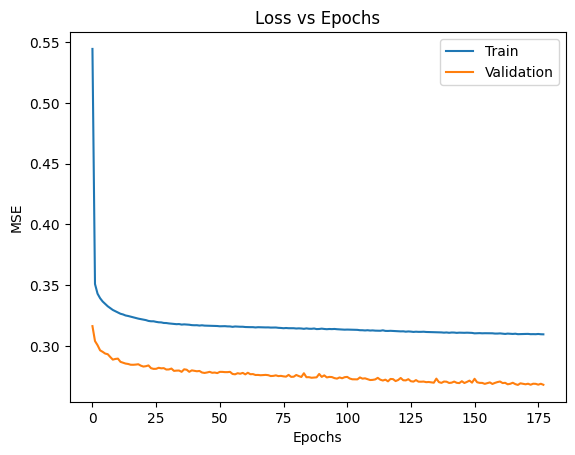

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

In [29]:
test_loss, test_mae = model.evaluate(X_test, Y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3174 - mae: 0.4095
Test MSE: 0.3173719644546509
Test MAE: 0.40951454639434814


In [31]:
neuron_list = [5, 10, 15, 20, 25]
val_losses_neurons = []

for n in neuron_list:

    tf.keras.backend.clear_session()

    model = build_model(neurons=n, lr=0.0005)

    history = model.fit(
        X_train_full,
        Y_train_full,
        validation_split=0.1,
        epochs=125,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop, model_ckpt]
    )

    val_losses_neurons.append(min(history.history['val_loss']))

c:\Users\Ved\Desktop\ce6018\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


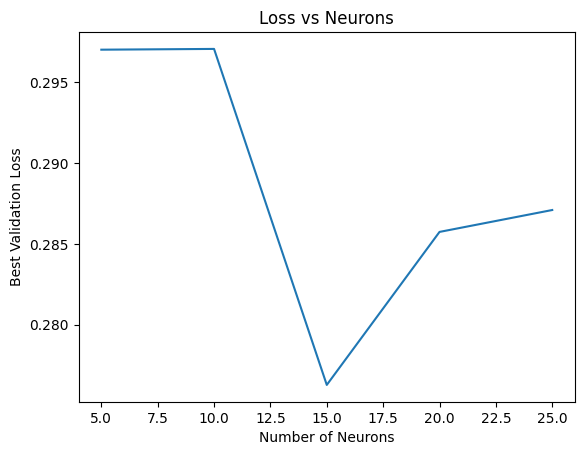

In [32]:
plt.figure()
plt.plot(neuron_list, val_losses_neurons)
plt.xlabel("Number of Neurons")
plt.ylabel("Best Validation Loss")
plt.title("Loss vs Neurons")
plt.show()

In [36]:
from tensorflow.keras.layers import Dense, Dropout, Input

def build_model(neurons=20, lr=0.0005, dropout_rate=0.0):

    input_dim = X_train_full.shape[1]

    model = tf.keras.Sequential([
        Input(shape=(input_dim,)), # Explicit Input layer
        Dense(neurons, activation='relu'),
        Dense(neurons, activation='relu')
    ])

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(Y_train_full.shape[1], activation='linear'))

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [33]:
best_neurons = neuron_list[np.argmin(val_losses_neurons)]


print("Best neurons:", best_neurons)


Best neurons: 15


In [37]:
lr_list = [0.0005, 0.001, 0.005, 0.01]

train_mae_no = []
val_mae_no = []

train_mae_do = []
val_mae_do = []

for lr in lr_list:

    # -------- No Dropout ----------
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr, dropout_rate=0.0)

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop, model_ckpt]
    )

    train_mae_no.append(history.history['mae'][-1])
    val_mae_no.append(history.history['val_mae'][-1])

    # -------- With Dropout ----------
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr, dropout_rate=0.05)

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop, model_ckpt]
    )

    train_mae_do.append(history.history['mae'][-1])
    val_mae_do.append(history.history['val_mae'][-1])

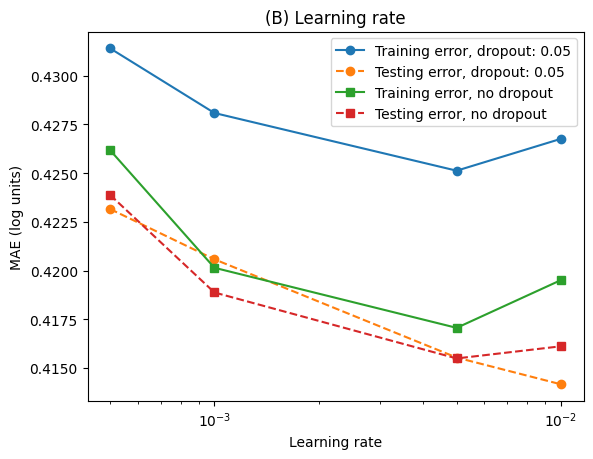

In [38]:
plt.figure()

plt.plot(lr_list, train_mae_do, marker='o', label="Training error, dropout: 0.05")
plt.plot(lr_list, val_mae_do, marker='o', linestyle='--', label="Testing error, dropout: 0.05")

plt.plot(lr_list, train_mae_no, marker='s', label="Training error, no dropout")
plt.plot(lr_list, val_mae_no, marker='s', linestyle='--', label="Testing error, no dropout")

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("MAE (log units)")
plt.title("(B) Learning rate")
plt.legend()
plt.show()

In [39]:
batch_list = [16, 32, 64, 128, 256]
val_losses_batch = []

In [40]:
batch_list = [16, 32, 64, 128, 256]

lr_compare = [0.001, 0.005]

train_mae_lr1 = []
val_mae_lr1 = []

train_mae_lr2 = []
val_mae_lr2 = []

for b in batch_list:

    # ----- LR 1 -----
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr_compare[0])

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=b,
        verbose=0,
        callbacks=[early_stop, model_ckpt]
    )

    train_mae_lr1.append(history.history['mae'][-1])
    val_mae_lr1.append(history.history['val_mae'][-1])

    # ----- LR 2 -----
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr_compare[1])

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=b,
        verbose=0,
        callbacks=[early_stop, model_ckpt]
    )

    train_mae_lr2.append(history.history['mae'][-1])
    val_mae_lr2.append(history.history['val_mae'][-1])

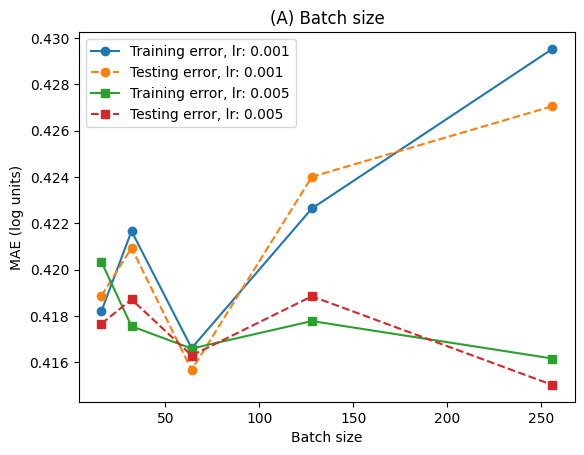

In [41]:
plt.figure()

plt.plot(batch_list, train_mae_lr1, marker='o', label=f"Training error, lr: {lr_compare[0]}")
plt.plot(batch_list, val_mae_lr1, marker='o', linestyle='--', label=f"Testing error, lr: {lr_compare[0]}")

plt.plot(batch_list, train_mae_lr2, marker='s', label=f"Training error, lr: {lr_compare[1]}")
plt.plot(batch_list, val_mae_lr2, marker='s', linestyle='--', label=f"Testing error, lr: {lr_compare[1]}")

plt.xlabel("Batch size")
plt.ylabel("MAE (log units)")
plt.title("(A) Batch size")
plt.legend()
plt.show()

In [42]:
lr_list = [0.01, 0.005, 0.001]
batch_list = [64, 128]

results = []

In [43]:
def build_model(lr):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(20, activation='relu', input_shape=(X_train_full.shape[1],)),
        tf.keras.layers.Dense(20, activation='relu'),
        tf.keras.layers.Dense(Y_train_full.shape[1])
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )

    return model


In [44]:
for lr in lr_list:
    for batch in batch_list:

        print(f"\nTraining: LR={lr}, Batch={batch}")

        model = build_model(lr)

        history = model.fit(
            X_train_full, Y_train_full,
            validation_split=0.1,
            epochs=125,
            batch_size=batch,
            verbose=0,
            callbacks=[early_stop, model_ckpt]
        )

        val_loss = min(history.history['val_loss'])
        val_mae  = min(history.history['val_mae'])

        results.append({
            'lr': lr,
            'batch': batch,
            'val_loss': val_loss,
            'val_mae': val_mae
        })



Training: LR=0.01, Batch=64

Training: LR=0.01, Batch=128

Training: LR=0.005, Batch=64

Training: LR=0.005, Batch=128

Training: LR=0.001, Batch=64

Training: LR=0.001, Batch=128


In [45]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df.sort_values("val_loss"))


      lr  batch  val_loss   val_mae
0  0.010     64  0.267384  0.404857
3  0.005    128  0.276226  0.411720
2  0.005     64  0.278978  0.414392
1  0.010    128  0.279682  0.415032
4  0.001     64  0.282370  0.416917
5  0.001    128  0.284849  0.419400


In [46]:
best = results_df.loc[results_df['val_loss'].idxmin()]

print("\n BEST SETTINGS:")
print("Learning Rate:", best['lr'])
print("Batch Size:", best['batch'])



 BEST SETTINGS:
Learning Rate: 0.01
Batch Size: 64.0


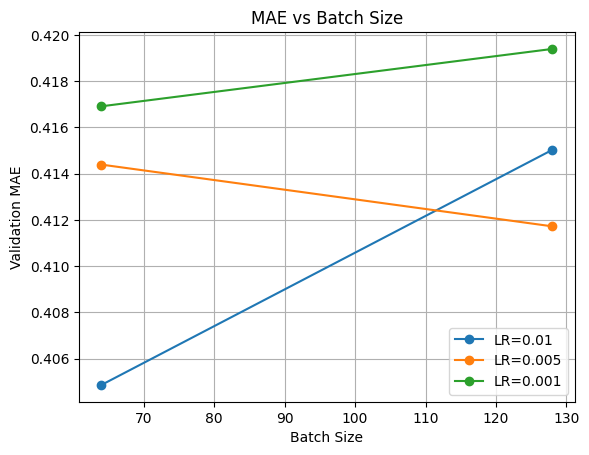

In [47]:
plt.figure()

for lr in lr_list:
    subset = results_df[results_df['lr'] == lr]
    plt.plot(subset['batch'], subset['val_mae'], marker='o', label=f"LR={lr}")

plt.xlabel("Batch Size")
plt.ylabel("Validation MAE")
plt.title("MAE vs Batch Size")
plt.legend()
plt.grid(True)
plt.show()

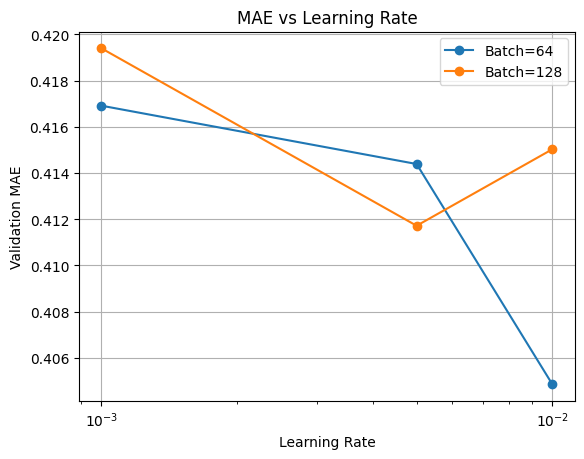

In [48]:
plt.figure()

for batch in batch_list:
    subset = results_df[results_df['batch'] == batch]
    plt.plot(subset['lr'], subset['val_mae'], marker='o', label=f"Batch={batch}")

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation MAE")
plt.title("MAE vs Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
BEST_LR = 0.01
BEST_BATCH = 64
BEST_NEURONS = 15
EPOCHS = 125

X_final = X_train_full
Y_final = Y_train_full


In [50]:
def build_final_model():

    input_dim = X_final.shape[1]

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)), # Explicit Input layer
        tf.keras.layers.Dense(BEST_NEURONS, activation='relu'),
        tf.keras.layers.Dense(BEST_NEURONS, activation='relu'),
        tf.keras.layers.Dropout(0.05),   # keep — helps generalization
        tf.keras.layers.Dense(Y_final.shape[1])
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LR),
        loss='mse',
        metrics=['mae']
    )

    return model

In [51]:
final_model = build_final_model()

history = final_model.fit(
    X_final, Y_final,
    epochs=200,
    batch_size=BEST_BATCH,
    validation_split=0.1,   # small internal check
    verbose=1,
    callbacks=[early_stop, model_ckpt]
)


Epoch 1/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3747 - mae: 0.4524 - val_loss: 0.2931 - val_mae: 0.4254
Epoch 2/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3449 - mae: 0.4349 - val_loss: 0.2897 - val_mae: 0.4221
Epoch 3/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3426 - mae: 0.4322 - val_loss: 0.2961 - val_mae: 0.4256
Epoch 4/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3414 - mae: 0.4311 - val_loss: 0.2883 - val_mae: 0.4217
Epoch 5/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3409 - mae: 0.4302 - val_loss: 0.2936 - val_mae: 0.4242
Epoch 6/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3394 - mae: 0.4292 - val_loss: 0.2885 - val_mae: 0.4216
Epoch 7/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3381 - mae: 0.4285 - val_loss: 0.2972 - val_mae: 0.4289
Epoch 8/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3380 - mae: 0.4292 - val_loss: 0.2945 - val_mae: 0.4241
Epoch 9/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

In [52]:
test_loss, test_mae = final_model.evaluate(X_test, Y_test)

print("\n FINAL TEST PERFORMANCE")
print("Test Loss:", test_loss)
print("Test MAE :", test_mae)


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3412 - mae: 0.4292

 FINAL TEST PERFORMANCE
Test Loss: 0.34122946858406067
Test MAE : 0.429214745759964


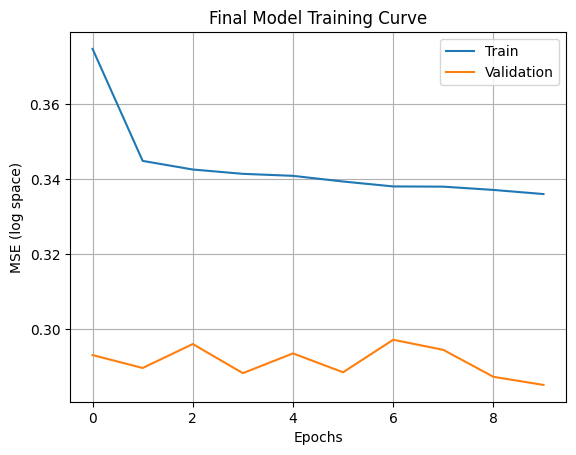

In [53]:
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel("Epochs")
plt.ylabel("MSE (log space)")
plt.title("Final Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [54]:
final_model.save("GMPE_ANN_Final_Model.keras")
print("Model Saved!")

Model Saved!


In [56]:
Y_pred = final_model.predict(X_test)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [57]:
pga_obs = Y_test[:, 0]
pga_pred = Y_pred[:, 0]

residuals = pga_obs - pga_pred

In [58]:
X_test_unscaled = scaler_X.inverse_transform(X_test)
M_test = X_test_unscaled[:, 0]     # Magnitude (M)
R_test = X_test_unscaled[:, 3]     # Rjb (R)
Vs_test = 10**(X_test_unscaled[:, 2])    # Vs30 (from log_Vs30)


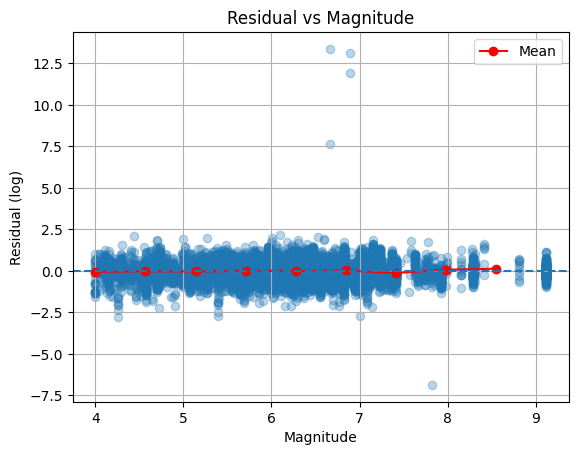

In [59]:
plt.figure()

plt.scatter(M_test, residuals, alpha=0.3)

# Mean in bins
bins = np.linspace(min(M_test), max(M_test), 10)
digitized = np.digitize(M_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Magnitude")
plt.ylabel("Residual (log)")
plt.title("Residual vs Magnitude")
plt.legend()
plt.grid(True)
plt.show()

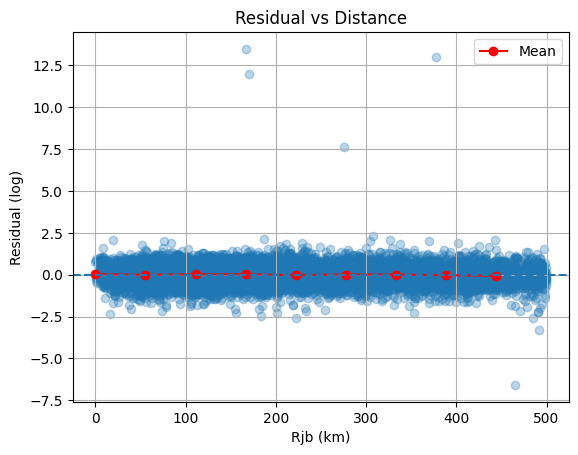

In [56]:
plt.figure()

plt.scatter(R_test, residuals, alpha=0.3)

bins = np.linspace(min(R_test), max(R_test), 10)
digitized = np.digitize(R_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Rjb (km)")
plt.ylabel("Residual (log)")
plt.title("Residual vs Distance")
plt.legend()
plt.grid(True)
plt.show()

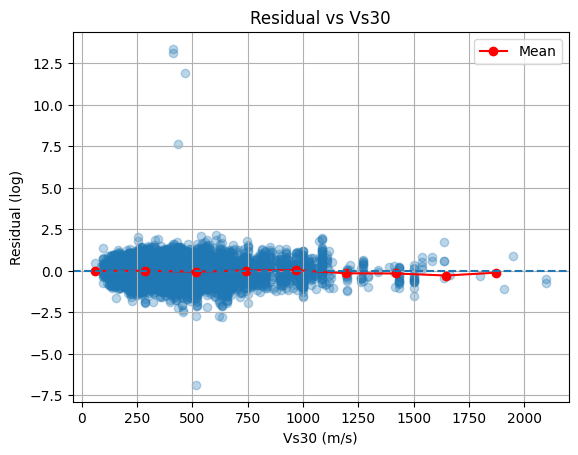

In [60]:
plt.figure()

plt.scatter(Vs_test, residuals, alpha=0.3)

bins = np.linspace(min(Vs_test), max(Vs_test), 10)
digitized = np.digitize(Vs_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Vs30 (m/s)")
plt.ylabel("Residual (log)")
plt.title("Residual vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
import re

psa_cols = [col for col in df.columns if col.startswith("T") and col.endswith("S")]

def col_to_period(col):
    num = col.replace("T","").replace("S","").replace("pt",".")
    return float(num)

periods = [col_to_period(col) for col in psa_cols]

In [62]:
print(periods)

[0.01, 0.02, 0.022, 0.025, 0.029, 0.03, 0.032, 0.035, 0.036, 0.04, 0.042, 0.044, 0.045, 0.046, 0.048, 0.05, 0.055, 0.06, 0.065, 0.067, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.11, 0.12, 0.13, 0.133, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.22, 0.24, 0.25, 0.26, 0.28, 0.29, 0.3, 0.32, 0.34, 0.35, 0.36, 0.38, 0.4, 0.42, 0.44, 0.45, 0.46, 0.48, 0.5, 0.55, 0.6, 0.65, 0.667, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.2, 2.4, 2.5, 2.6, 2.8, 3.0, 3.2, 3.4, 3.5, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 20.0]


In [66]:
mag_groups = {
    "Mw 4": (3.9, 4.1),
    "Mw 5": (4.9, 5.1),
    "Mw 6": (5.9, 6.1),
    "Mw 7+": (7.0, 10.0)
}

In [70]:
plt.figure()

# Predict PSA for fixed Rjb and Vs30 at specified magnitudes and plot vs period
fixed_R = 10.0    # Rjb (km)
fixed_Vs30 = 760.0  # Vs30 (m/s)
fm_default = 0.0
mags = [4.0, 5.0, 6.0, 7.0, 7.5]

# Build inputs matching input_cols = ["M", "log_R", "log_Vs30", "R", "FM"]
X_query = []
for m in mags:
    log_R = np.log10(fixed_R)
    log_Vs = np.log10(fixed_Vs30)
    X_query.append([m, log_R, log_Vs, fixed_R, fm_default])

X_query = np.array(X_query)
X_query_scaled = scaler_X.transform(X_query)

# Predict and inverse-transform outputs to get original log-PSA outputs
Y_pred_scaled = final_model.predict(X_query_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)  # now in original output units (log_PGA, log_PGV, log_...)

# Identify spectral output columns and derive periods for x-axis
spec_cols = [c for c in output_cols if 'sec' in c]
def _col_to_period(col):
    s = col.replace('log_', '')
    s = s.replace('_', ' ').replace(' sec', '').strip()
    try:
        return float(s)
    except:
        num = ''.join(ch for ch in s if ch.isdigit() or ch=='.')
        return float(num)

model_plot_periods = np.array([_col_to_period(c) for c in spec_cols])

# Extract spectral predictions (in log units) and plot
spec_indices = [output_cols.index(c) for c in spec_cols]
psa_preds_log = Y_pred[:, spec_indices]  # shape (len(mags), n_periods)

# Plot 1: log x-axis (time in log) — PSA remains in log units
plt.figure()
for i, m in enumerate(mags):
    plt.plot(model_plot_periods, psa_preds_log[i, :], marker='o', label=f'M={m}')
plt.xscale('log')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period (log x-axis) — PSA in log units')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: linear x-axis — PSA still in log units
plt.figure()
for i, m in enumerate(mags):
    plt.plot(model_plot_periods, psa_preds_log[i, :], marker='o', label=f'M={m}')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period (linear x-axis) — PSA in log units')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


ValueError: could not convert string to float: ''

<Figure size 640x480 with 0 Axes>

In [79]:
X_param_groups = {}

for label, (low, high) in mag_groups.items():

    subset = clean_df[(clean_df["M"] >= low) &
                      (clean_df["M"] <= high)]

    X_m = subset[input_cols].values
    X_param_groups[label] = scaler_X.transform(X_m)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


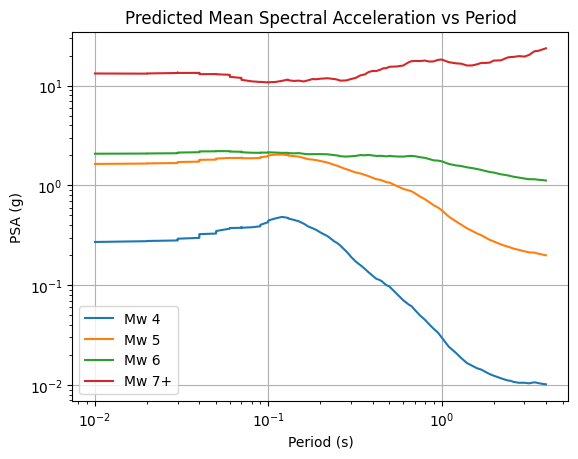

In [88]:
plt.figure()

# Get the list of actual predicted SA output column names from output_cols
# Exclude 'log_PGA', 'log_PGV', and 'log_PGV_cm_sec' as they are not spectral accelerations
predicted_sa_output_col_names = [col for col in output_cols if col.startswith('log_') and 'sec' in col and col != 'log_PGV_cm_sec']

def extract_period_from_model_output_col(log_col_name):
    # Remove 'log_' prefix
    period_str = log_col_name.replace('log_', '')
    # Remove ' sec' suffix (note the space before sec)
    period_str = period_str.replace(' sec', '')
    # Handle cases where duplicates caused an underscore suffix (e.g., '0.02_1')
    if '_' in period_str and len(period_str.split('_')) > 1 and period_str.split('_')[-1].isdigit():
        period_str = '_'.join(period_str.split('_')[:-1])
    return float(period_str)

# Create the periods list for plotting the predicted SA values
model_plot_periods = [extract_period_from_model_output_col(col) for col in predicted_sa_output_col_names]

for label in mag_groups.keys():

    Y_pred = final_model.predict(X_param_groups[label])

    # Correctly select only spectral accelerations (excluding PGA, PGV, and PGV_cm_sec)
    psa_pred = Y_pred[:, 3:]
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("PSA (g)")
plt.title("Predicted Mean Spectral Acceleration vs Period")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
dist_groups = {
    "R = 10 km": (0, 15),
    "R = 22 km": (15, 35),
    "R = 50 km": (35, 75),
    "R = 110 km": (75, 150),
    "R = 250 km": (150, 400)
}

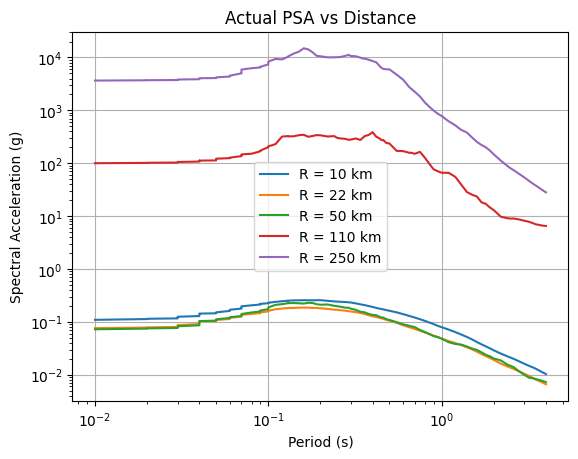

In [89]:
plt.figure()

for label, (low, high) in dist_groups.items():

    subset = clean_df[(clean_df["R"] >= low) &
                      (clean_df["R"] < high)]

    mean_psa = subset[actual_sa_plot_cols].mean().values

    plt.plot(model_plot_periods, mean_psa, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Actual PSA vs Distance")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
print("Example mean_psa values from the last plot (Actual PSA vs Distance):")
# Re-calculate mean_psa for one of the distance groups to inspect values
label, (low, high) = list(dist_groups.items())[0] # Take the first group as an example
subset = clean_df[(clean_df["R"] >= low) &
                  (clean_df["R"] < high)]
mean_psa = subset[actual_sa_plot_cols].mean().values
print(mean_psa)
print(f"Max mean PSA: {mean_psa.max()}")
print(f"Min mean PSA: {mean_psa.min()}")

Example mean_psa values from the last plot (Actual PSA vs Distance):
[0.10921559 0.11293291 0.11433477 0.11627842 0.12057121 0.1219993
 0.12489061 0.12886068 0.13018469 0.1362275  0.13910912 0.14165584
 0.14332026 0.14514549 0.14789515 0.15129604 0.16107108 0.16932835
 0.17828062 0.18167169 0.18678509 0.1970613  0.20529772 0.21306139
 0.21922713 0.22508544 0.23004506 0.23849032 0.24530437 0.25042219
 0.25194818 0.25452494 0.25554205 0.25652376 0.25624006 0.25526505
 0.25681536 0.25719031 0.24976302 0.24368031 0.2418591  0.23981946
 0.23696133 0.23419636 0.2320678  0.22347775 0.2146428  0.21060222
 0.20700138 0.19892124 0.1912695  0.18346811 0.17727914 0.17468216
 0.17232301 0.16670224 0.16225563 0.15117631 0.13981938 0.12947092
 0.12598035 0.12059061 0.11218708 0.10442863 0.09712839 0.09054333
 0.08422814 0.07938765 0.07124037 0.06405709 0.05738744 0.05175706
 0.04656916 0.04145187 0.03757996 0.03437699 0.03154488 0.02894816
 0.02505536 0.02224998 0.02111823 0.01999796 0.01791735 0.016

In [91]:
X_dist_groups = {}

for label, (low, high) in dist_groups.items():

    subset = clean_df[(clean_df["R"] >= low) &
                      (clean_df["R"] < high)]

    X_m = subset[input_cols].values
    X_dist_groups[label] = scaler_X.transform(X_m)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


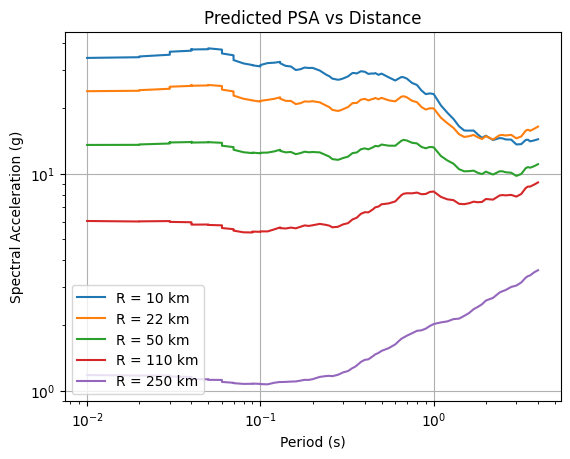

In [93]:
plt.figure()

for label in dist_groups.keys():

    Y_pred = final_model.predict(X_dist_groups[label])

    psa_pred = Y_pred[:, 3:]   # remove log_PGA, log_PGV, and log_PGV_cm_sec
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Predicted PSA vs Distance")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
vs_groups = {
    "Vs30 < 200 (Soft Soil)": (0, 200),
    "200 - 400": (200, 400),
    "400 - 600": (400, 600),
    "600 - 800": (600, 800),
    "> 800 (Hard Rock)": (800, 2000)
}

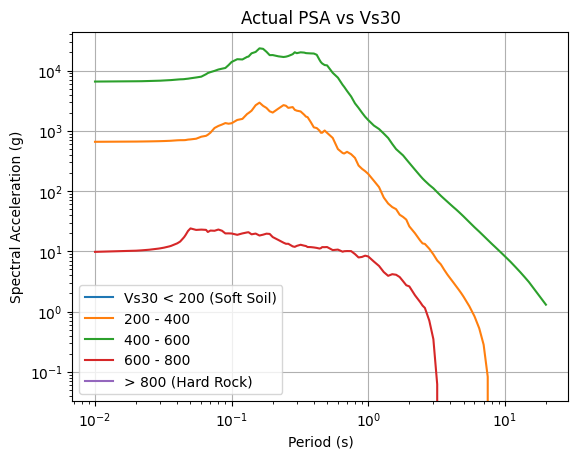

In [95]:
plt.figure()

for label, (low, high) in vs_groups.items():

    subset = df[(df["Vs30_Selected_for_Analysis_m_s"] >= low) &
                (df["Vs30_Selected_for_Analysis_m_s"] < high)]

    mean_psa = subset[psa_cols].mean().values

    plt.plot(periods, mean_psa, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Actual PSA vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [97]:
X_vs_groups = {}

for label, (low, high) in vs_groups.items():

    subset = clean_df[(clean_df["Vs30"] >= low) &
                      (clean_df["Vs30"] < high)]

    X_m = subset[input_cols].values
    X_vs_groups[label] = scaler_X.transform(X_m)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


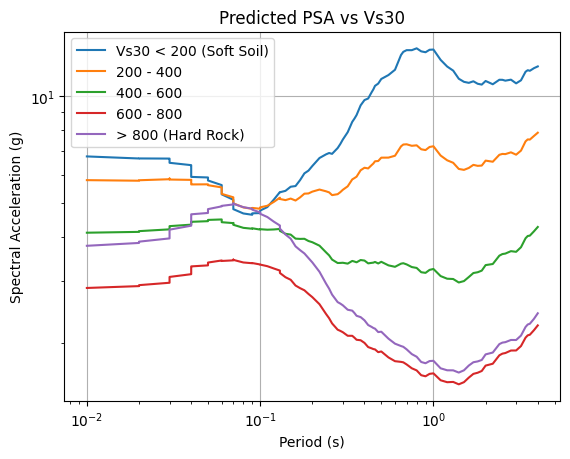

In [99]:
plt.figure()

for label in vs_groups.keys():

    Y_pred = final_model.predict(X_vs_groups[label])

    psa_pred = Y_pred[:, 3:]   # remove log_PGA, log_PGV, and log_PGV_cm_sec
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Predicted PSA vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
from sklearn.metrics import mean_squared_error
import numpy as np

# baseline prediction
Y_base = final_model.predict(X_test)

baseline_error = mean_squared_error(Y_test, Y_base)

print("Baseline MSE:", baseline_error)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline MSE: 0.33225507355525974


In [103]:
feature_names = ["M", "log_R", "log_Vs30", "R", "FM"]
importance_scores = []

for i in range(X_test.shape[1]):

    X_permuted = X_test.copy()

    np.random.shuffle(X_permuted[:, i])   # disturb one feature

    Y_perm = final_model.predict(X_permuted)

    perm_error = mean_squared_error(Y_test, Y_perm);

    importance = perm_error - baseline_error

    importance_scores.append(importance)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


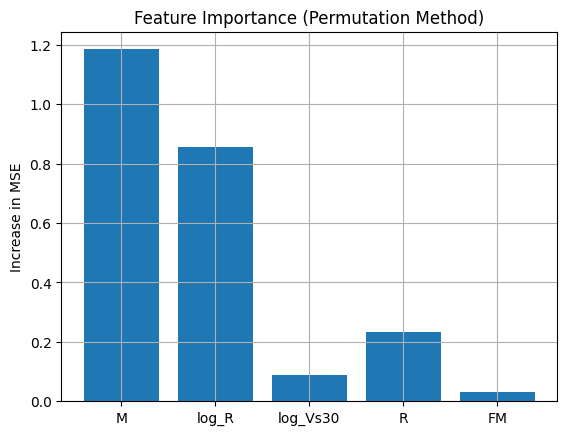

In [104]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(feature_names, importance_scores)

plt.ylabel("Increase in MSE")
plt.title("Feature Importance (Permutation Method)")
plt.grid(True)

plt.show()

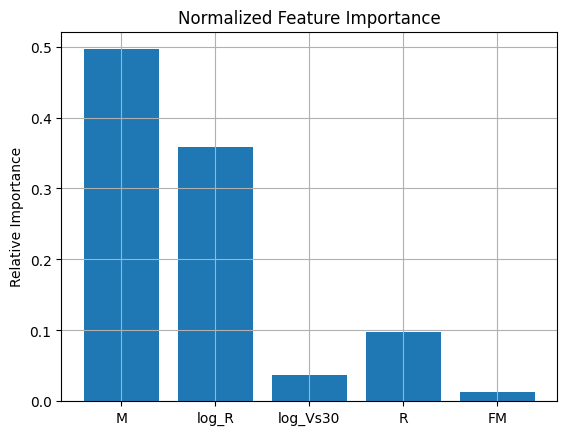

In [106]:
importance_norm = np.array(importance_scores) / np.sum(importance_scores)

plt.figure()

plt.bar(feature_names, importance_norm)

plt.ylabel("Relative Importance")
plt.title("Normalized Feature Importance")
plt.grid(True)

plt.show()

In [107]:
pip install shap

In [108]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [109]:
feature_names = [
    "Magnitude",
    "Rrup",
    "log(Vs30)",
    "log(Rrup)",
    "Fault Mechanism"
]

In [111]:
# Take small background sample
background = X_train_full[np.random.choice(X_train_full.shape[0], 200, replace=False)]

explainer = shap.DeepExplainer(model, background)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(200, 5))']
  warnings.warn(msg)


In [112]:
shap_values = explainer.shap_values(X_test[:300])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)


KeyboardInterrupt: 

In [115]:
# Take small background sample
background = X_train_full[np.random.choice(X_train_full.shape[0], 200, replace=False)]

explainer = shap.DeepExplainer(model, background)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(200, 5))']
  warnings.warn(msg)


In [ ]:
shap_values = explainer.shap_values(X_test[:300])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


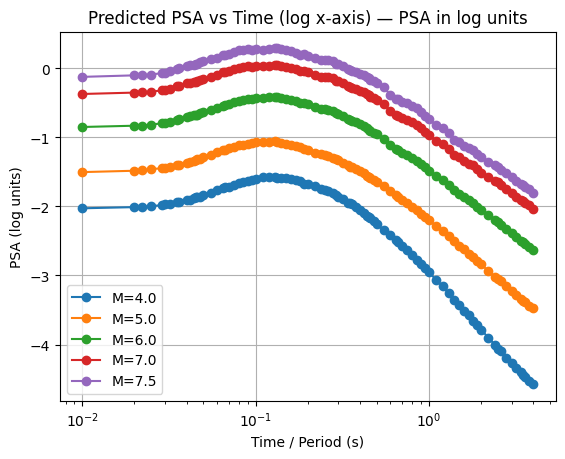

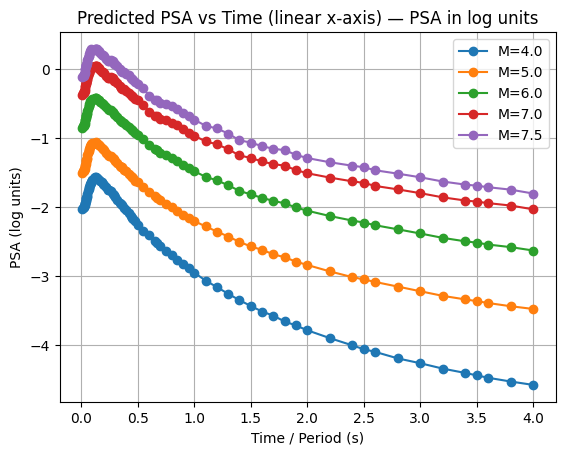

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


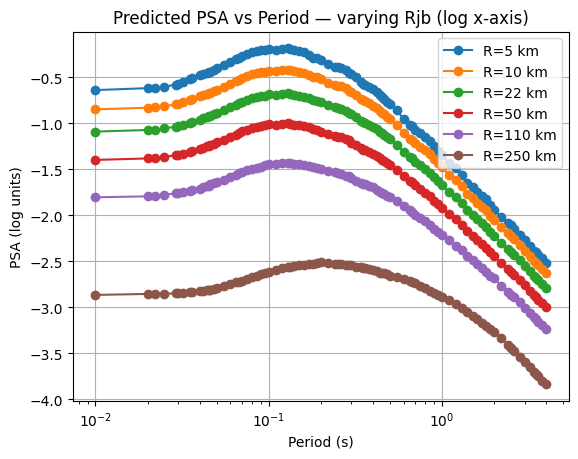

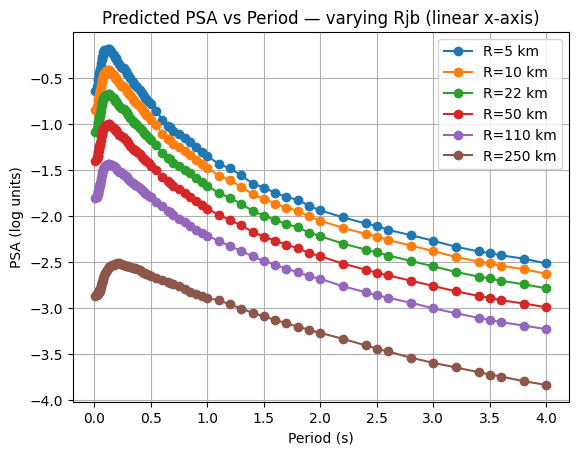

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


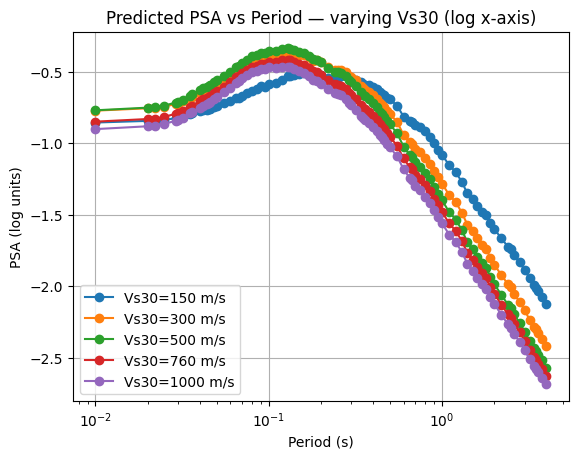

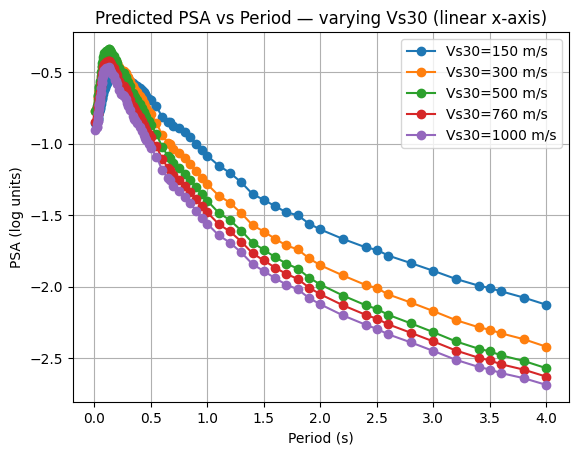

In [72]:
# Generate predicted PSA vs time for fixed Rjb and Vs30 for specified magnitudes
# Fixed parameter values
fixed_R = 10.0    # Rjb (km)
fixed_Vs30 = 760.0  # Vs30 (m/s)
fm_default = 0.0   # Fault mechanism numeric placeholder

mags = [4.0, 5.0, 6.0, 7.0, 7.5]

# Build input matrix matching input_cols = ["M","log_R","log_Vs30","R","FM"]
X_query = []
for m in mags:
    log_R = np.log10(fixed_R)
    log_Vs = np.log10(fixed_Vs30)
    X_query.append([m, log_R, log_Vs, fixed_R, fm_default])

X_query = np.array(X_query)
X_query_scaled = scaler_X.transform(X_query)

# Predict and inverse-transform outputs to get original log-PSA outputs
Y_pred_scaled = final_model.predict(X_query_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)  # now in original output units (log_PGA, log_PGV, log_...)

# Identify spectral output columns (those containing 'sec') and extract numeric periods robustly
import re
spec_cols = [c for c in output_cols if 'sec' in c]
periods = []
period_cols = []
for col in spec_cols:
    s = col.replace('log_', '').replace('_', ' ').replace(' sec', ' ').strip()
    m = re.search(r'(\d+\.\d+|\d+)', s)
    if m:
        periods.append(float(m.group(1)))
        period_cols.append(col)
# Ensure we found at least one spectral period column
if len(periods) == 0:
    raise ValueError('No spectral period columns found in output_cols')
model_plot_periods = np.array(periods)
# Use only the columns that had an extracted period
spec_cols = period_cols

# Extract spectral predictions from Y_pred using indices
spec_indices = [output_cols.index(c) for c in spec_cols]
psa_preds_log = Y_pred[:, spec_indices]   # shape (len(mags), n_periods) ; PSA in log units

# Plot 1: time (period) on log x-axis, PSA in log units
plt.figure()
for i, m in enumerate(mags):
    plt.plot(model_plot_periods, psa_preds_log[i, :], marker='o', label=f'M={m}')
plt.xscale('log')
plt.xlabel('Time / Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Time (log x-axis) — PSA in log units')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: time on linear x-axis
plt.figure()
for i, m in enumerate(mags):
    plt.plot(model_plot_periods, psa_preds_log[i, :], marker='o', label=f'M={m}')
plt.xlabel('Time / Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Time (linear x-axis) — PSA in log units')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------- Rjb (rupture distance) sweep --------------------------
# Keep magnitude and Vs30 constant, vary Rjb
fixed_M = 6.0
fixed_Vs30 = 760.0
R_list = [5.0, 10.0, 22.0, 50.0, 110.0, 250.0]
X_query = []
for Rval in R_list:
    log_R = np.log10(Rval)
    log_Vs = np.log10(fixed_Vs30)
    X_query.append([fixed_M, log_R, log_Vs, Rval, fm_default])
X_query = np.array(X_query)
Xq_scaled = scaler_X.transform(X_query)
Yq_scaled = final_model.predict(Xq_scaled)
Yq = scaler_Y.inverse_transform(Yq_scaled)
psa_q_log = Yq[:, spec_indices]

plt.figure()
for i, Rval in enumerate(R_list):
    plt.plot(model_plot_periods, psa_q_log[i, :], marker='o', label=f'R={int(Rval)} km')
plt.xscale('log')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period — varying Rjb (log x-axis)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for i, Rval in enumerate(R_list):
    plt.plot(model_plot_periods, psa_q_log[i, :], marker='o', label=f'R={int(Rval)} km')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period — varying Rjb (linear x-axis)')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------- Vs30 sweep --------------------------
# Keep magnitude and Rjb constant, vary Vs30
fixed_M = 6.0
fixed_R = 10.0
Vs_list = [150.0, 300.0, 500.0, 760.0, 1000.0]
X_query = []
for Vs in Vs_list:
    log_R = np.log10(fixed_R)
    log_Vs = np.log10(Vs)
    X_query.append([fixed_M, log_R, log_Vs, fixed_R, fm_default])
X_query = np.array(X_query)
Xq_scaled = scaler_X.transform(X_query)
Yq_scaled = final_model.predict(Xq_scaled)
Yq = scaler_Y.inverse_transform(Yq_scaled)
psa_v_log = Yq[:, spec_indices]

plt.figure()
for i, Vs in enumerate(Vs_list):
    plt.plot(model_plot_periods, psa_v_log[i, :], marker='o', label=f'Vs30={int(Vs)} m/s')
plt.xscale('log')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period — varying Vs30 (log x-axis)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for i, Vs in enumerate(Vs_list):
    plt.plot(model_plot_periods, psa_v_log[i, :], marker='o', label=f'Vs30={int(Vs)} m/s')
plt.xlabel('Period (s)')
plt.ylabel('PSA (log units)')
plt.title('Predicted PSA vs Period — varying Vs30 (linear x-axis)')
plt.legend()
plt.grid(True)
plt.show()


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline MSE: 0.34122940482093966
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


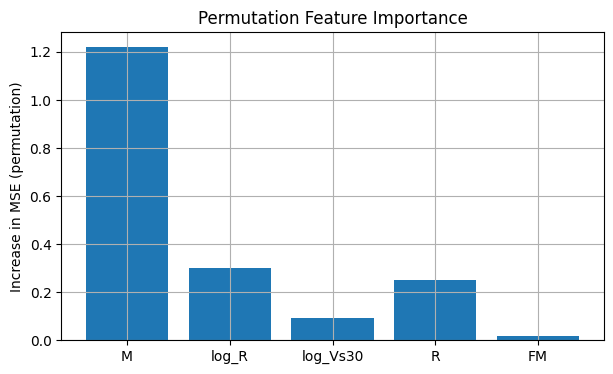

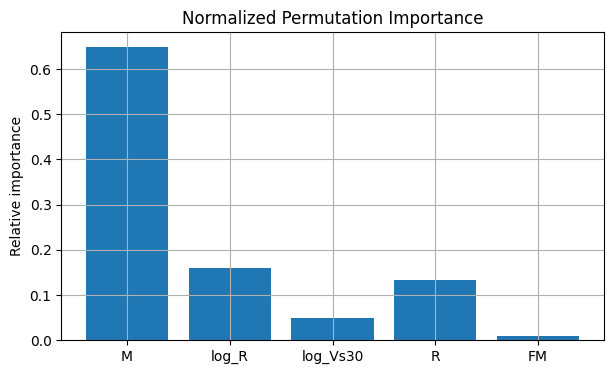

SHAP not available or failed: No module named 'shap'
To use SHAP, install it with: %pip install shap and restart kernel.


In [73]:
# Feature importance: permutation and SHAP (optional)
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["M", "log_R", "log_Vs30", "R", "FM"]

# Baseline prediction (on test set)
Y_base = final_model.predict(X_test)
baseline_error = mean_squared_error(Y_test, Y_base)
print("Baseline MSE:", baseline_error)

# Permutation importance
importance_scores = []
for i in range(X_test.shape[1]):
    X_perm = X_test.copy()
    rng = np.random.default_rng(seed=42)
    rng.shuffle(X_perm[:, i])
    Y_perm = final_model.predict(X_perm)
    perm_error = mean_squared_error(Y_test, Y_perm)
    importance_scores.append(perm_error - baseline_error)

# Plot permutation importance (absolute increase in MSE)
plt.figure(figsize=(7,4))
plt.bar(feature_names, importance_scores)
plt.ylabel("Increase in MSE (permutation)")
plt.title("Permutation Feature Importance")
plt.grid(True)
plt.show()

# Normalized
importance_norm = np.array(importance_scores)
importance_norm = importance_norm / (importance_norm.sum() + 1e-12)
plt.figure(figsize=(7,4))
plt.bar(feature_names, importance_norm)
plt.ylabel("Relative importance")
plt.title("Normalized Permutation Importance")
plt.grid(True)
plt.show()

# SHAP importance (optional)
try:
    import shap
    # use small background sample
    n_bg = min(200, X_train_full.shape[0])
    background = X_train_full[np.random.choice(X_train_full.shape[0], n_bg, replace=False)]
    explainer = shap.DeepExplainer(final_model, background)
    sv = explainer.shap_values(X_test[:200])
    # sv may be list (per output) or array
    if isinstance(sv, list):
        # average abs across outputs and samples -> feature importances
        abs_vals = np.mean([np.abs(s) for s in sv], axis=(0,1))
    else:
        abs_vals = np.mean(np.abs(sv), axis=0)
    rel = abs_vals / (abs_vals.sum() + 1e-12)
    plt.figure(figsize=(7,4))
    plt.bar(feature_names, rel)
    plt.ylabel("Relative SHAP importance (avg |SHAP|)")
    plt.title("SHAP Feature Importance")
    plt.grid(True)
    plt.show()
except Exception as e:
    print("SHAP not available or failed:", e)
    print("To use SHAP, install it with: %pip install shap and restart kernel.")


SHAP library available. Proceeding with analysis...
Creating SHAP DeepExplainer...
Computing SHAP values for test samples...
SHAP values shape: 500 outputs, each (5, 93)
Number of input features: 93
Spectral output indices: [2, 3, 4, 5, 6]... (showing first 5)

Generating SHAP Summary Plots (force plot style)...


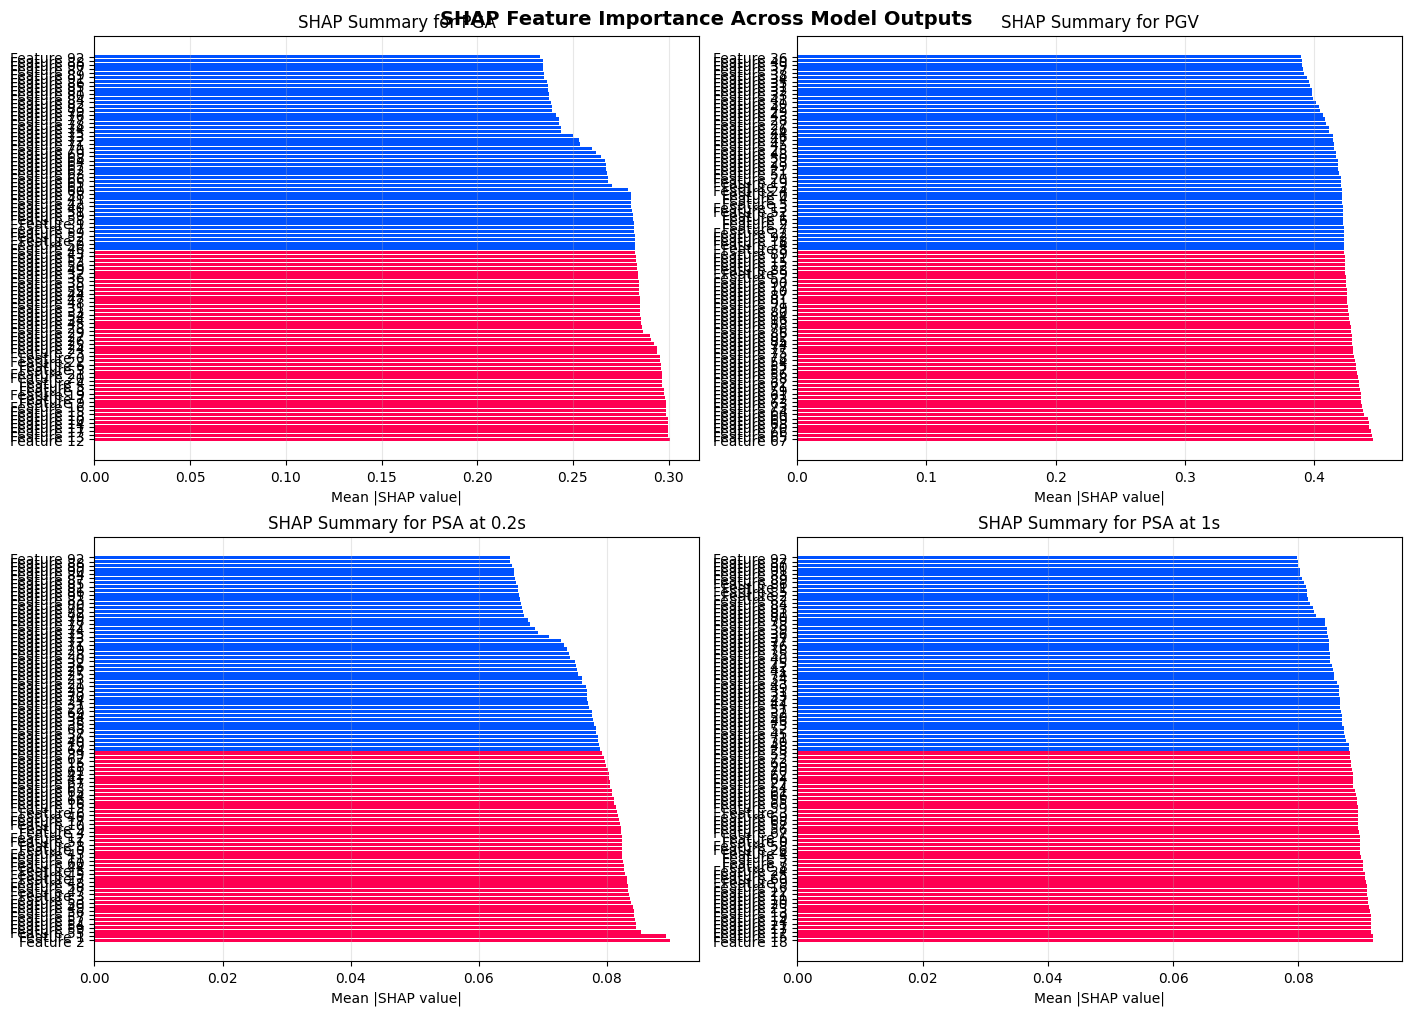


Generating SHAP Beeswarm Plots...


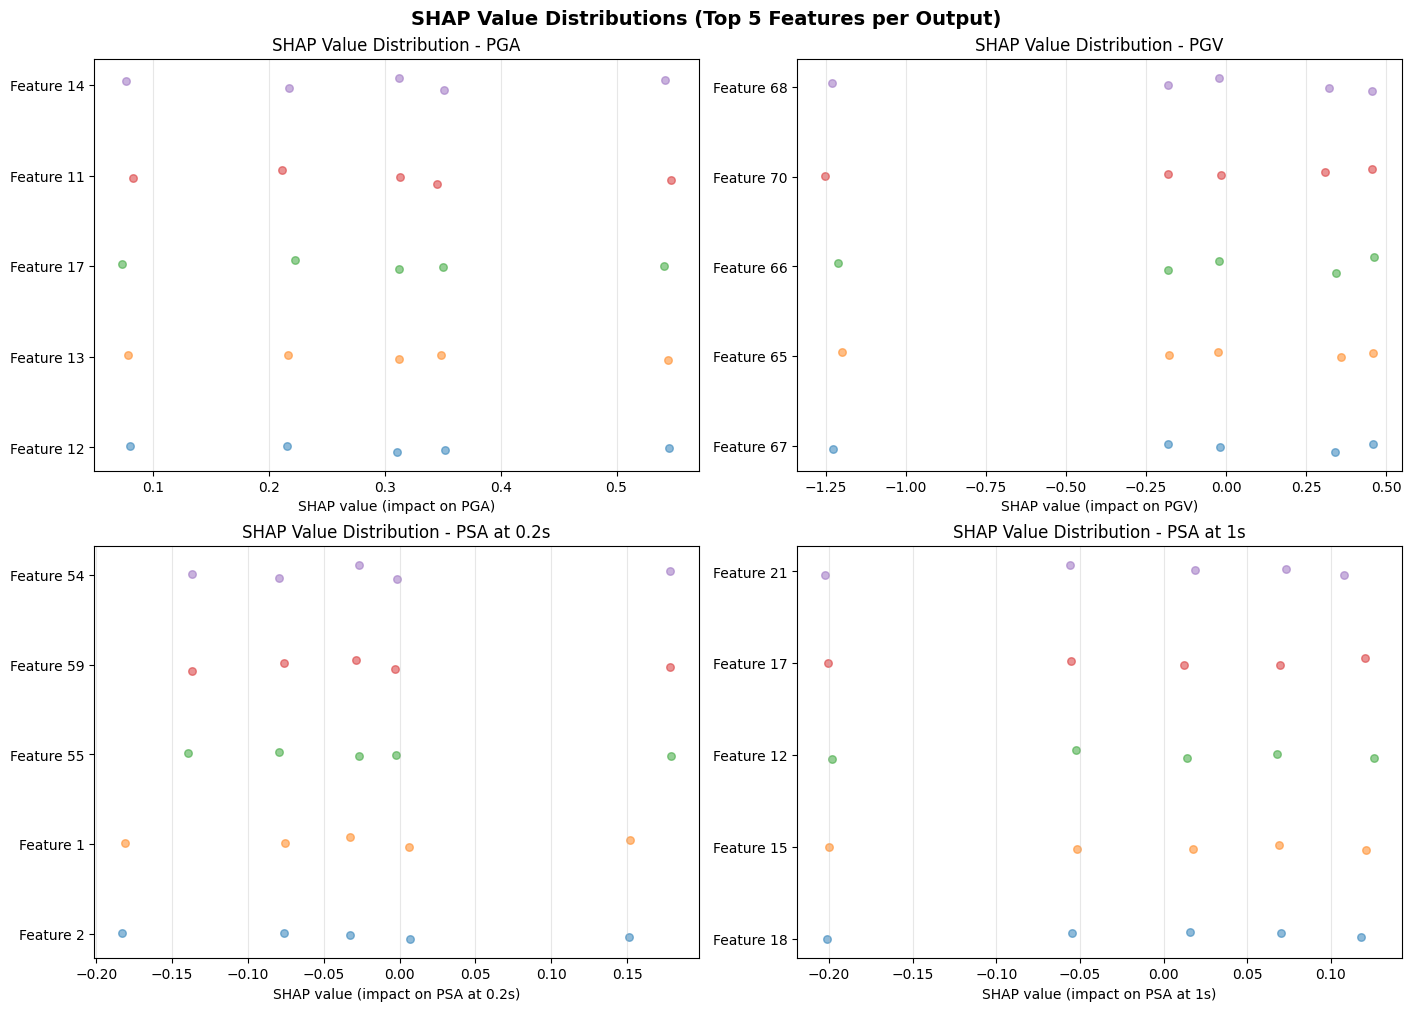


SHAP ANALYSIS SUMMARY

PGA:
  1. Feature 12: 0.3008
  2. Feature 13: 0.2999
  3. Feature 17: 0.2998

PGV:
  1. Feature 67: 0.4457
  2. Feature 65: 0.4447
  3. Feature 66: 0.4439

PSA at 0.2s:
  1. Feature 2: 0.0899
  2. Feature 1: 0.0894
  3. Feature 55: 0.0854

PSA at 1s:
  1. Feature 18: 0.0919
  2. Feature 15: 0.0919
  3. Feature 12: 0.0917



In [75]:
# SHAP Deep Explainer Analysis - Summary plots for select outputs
# Install SHAP if needed and create detailed explainability visualizations
import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    print("SHAP library available. Proceeding with analysis...")
except ImportError:
    print("Installing SHAP...")
    import subprocess
    subprocess.check_call(['pip', 'install', '-q', 'shap'])
    import shap

import numpy as np
import matplotlib.pyplot as plt

# Feature names for clarity (must match the actual number of input features)
feature_names = ["M", "log_R", "log_Vs30", "R", "FM"]

# Create SHAP explainer with background data
print("Creating SHAP DeepExplainer...")
n_bg = min(300, X_train_full.shape[0])
background_indices = np.random.choice(X_train_full.shape[0], n_bg, replace=False)
background_data = X_train_full[background_indices]

explainer = shap.DeepExplainer(final_model, background_data)

# Compute SHAP values for test set (use subset for speed)
print("Computing SHAP values for test samples...")
n_explain = min(500, X_test.shape[0])
test_data = X_test[:n_explain]
shap_values_list = explainer.shap_values(test_data)

# shap_values_list is a list (one per output), each is shape (n_samples, n_features)
print(f"SHAP values shape: {len(shap_values_list)} outputs, each {shap_values_list[0].shape}")
n_input_features = shap_values_list[0].shape[1]
print(f"Number of input features: {n_input_features}")

# Ensure feature_names matches actual number of features
if len(feature_names) != n_input_features:
    print(f"Warning: feature_names has {len(feature_names)} entries but SHAP has {n_input_features} features")
    feature_names = [f"Feature {i}" for i in range(n_input_features)]

# Select specific outputs to visualize: PGA (0), PGV (1), and a couple of spectral periods
# Find spectral column indices (those starting with 'log_' and containing 'sec')
spec_indices = [i for i, col in enumerate(output_cols) if col.startswith('log_') and 'sec' in col]
print(f"Spectral output indices: {spec_indices[:5] if len(spec_indices) > 0 else 'none'}... (showing first 5)")

# Select outputs to plot: PGA, PGV, and 2-3 spectral accelerations
outputs_to_plot = [
    (0, "PGA", "log_PGA"),
    (1, "PGV", "log_PGV"),
]

# Add 2 spectral accelerations (roughly at 0.2s and 1.0s if available)
if len(spec_indices) > 0:
    outputs_to_plot.append((spec_indices[min(1, len(spec_indices)-1)], "PSA at 0.2s", output_cols[spec_indices[min(1, len(spec_indices)-1)]]))
if len(spec_indices) > 3:
    outputs_to_plot.append((spec_indices[min(5, len(spec_indices)-1)], "PSA at 1s", output_cols[spec_indices[min(5, len(spec_indices)-1)]]))

# Create summary plots (SHAP values vs model output)
print("\nGenerating SHAP Summary Plots (force plot style)...")
n_rows = 2
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

for idx, (out_idx, label, col_name) in enumerate(outputs_to_plot):
    if idx >= len(axes):
        break
    ax = axes[idx]
    
    # Ensure out_idx is valid
    if out_idx >= len(shap_values_list):
        print(f"Skipping {label}: output index {out_idx} out of range ({len(shap_values_list)} outputs)")
        continue
    
    # Get SHAP values for this output
    shap_vals = shap_values_list[out_idx]  # shape (n_samples, n_features)
    
    # Compute mean absolute SHAP value per feature
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    # Sort by importance
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    
    # Ensure we don't exceed feature_names length
    sorted_idx = sorted_idx[:len(feature_names)]
    
    colors = ['#FF0051' if i < len(sorted_idx)//2 else '#0051FF' for i in range(len(sorted_idx))]
    
    ax.barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx], color=[colors[i] for i in range(len(sorted_idx))])
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[sorted_idx[i]] for i in range(len(sorted_idx))])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"SHAP Summary for {label}")
    ax.grid(axis='x', alpha=0.3)

# Hide unused subplots
for idx in range(len(outputs_to_plot), n_rows * n_cols):
    axes[idx].axis('off')

plt.suptitle("SHAP Feature Importance Across Model Outputs", fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Create detailed beeswarm plot (if available) - shows individual SHAP contributions
print("\nGenerating SHAP Beeswarm Plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

for idx, (out_idx, label, col_name) in enumerate(outputs_to_plot):
    if idx >= len(axes):
        break
    ax = axes[idx]
    
    # Ensure out_idx is valid
    if out_idx >= len(shap_values_list):
        continue
    
    shap_vals = shap_values_list[out_idx]
    
    # Create a simple scatter-style summary (top 5 features)
    feature_importance_idx = np.argsort(np.mean(np.abs(shap_vals), axis=0))[::-1][:5]
    
    for feat_rank, feat_idx in enumerate(feature_importance_idx):
        shap_data = shap_vals[:, feat_idx]
        y_pos = np.random.normal(feat_rank, 0.04, size=len(shap_data))
        ax.scatter(shap_data, y_pos, alpha=0.5, s=30)
    
    ax.set_yticks(range(len(feature_importance_idx)))
    ax.set_yticklabels([feature_names[feature_importance_idx[i]] for i in range(len(feature_importance_idx))])
    ax.set_xlabel(f"SHAP value (impact on {label})")
    ax.set_title(f"SHAP Value Distribution - {label}")
    ax.grid(axis='x', alpha=0.3)

# Hide unused subplots
for idx in range(len(outputs_to_plot), 4):
    axes[idx].axis('off')

plt.suptitle("SHAP Value Distributions (Top 5 Features per Output)", fontsize=14, fontweight='bold')
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SHAP ANALYSIS SUMMARY")
print("="*60)
for out_idx, label, col_name in outputs_to_plot:
    if out_idx >= len(shap_values_list):
        continue
    shap_vals = shap_values_list[out_idx]
    mean_abs = np.mean(np.abs(shap_vals), axis=0)
    top_features_idx = np.argsort(mean_abs)[::-1][:3]
    print(f"\n{label}:")
    for rank, feat_idx in enumerate(top_features_idx, 1):
        print(f"  {rank}. {feature_names[feat_idx]}: {mean_abs[feat_idx]:.4f}")

print("\n" + "="*60)


Shape diagnostics:
  test_data shape: (500, 5)
  shap_values_list shape: (500, 5, 93)

Generating SHAP Beeswarm Plots with Feature Value Color Encoding...

PGA: SHAP shape = (500, 5)


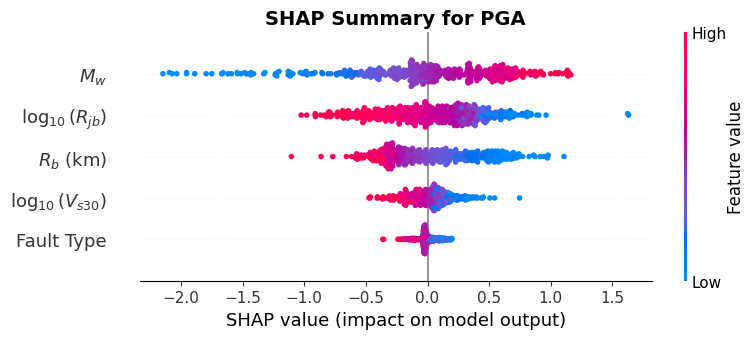


PGV: SHAP shape = (500, 5)


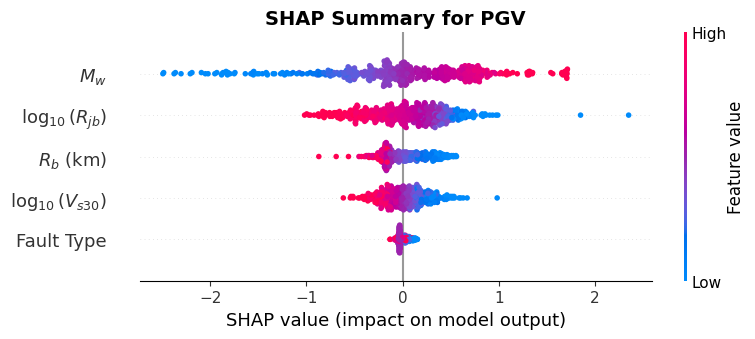


Sa(PGV cms): SHAP shape = (500, 5)


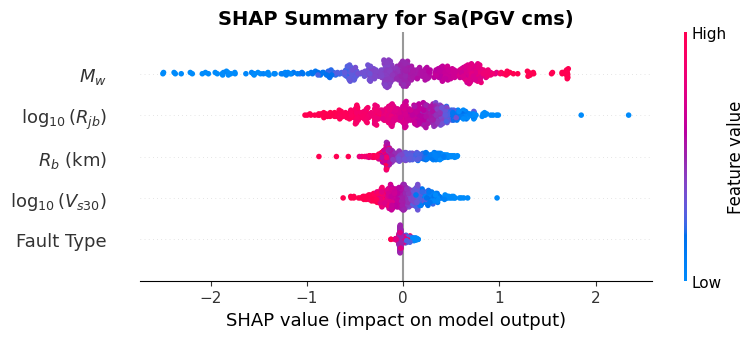


Sa(0.020s): SHAP shape = (500, 5)


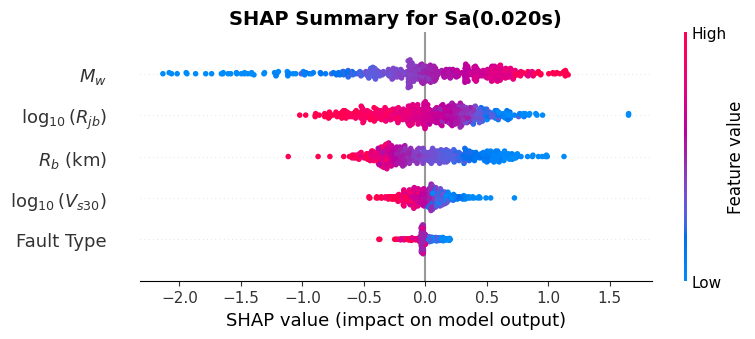


HOW TO INTERPRET BEESWARM PLOTS:

1. HORIZONTAL POSITION (X-axis):
   - Left (negative SHAP) = Feature DECREASES the prediction
   - Right (positive SHAP) = Feature INCREASES the prediction

2. COLOR:
   - RED dots = HIGH feature value
   - BLUE dots = LOW feature value

3. EXAMPLE INTERPRETATIONS:
   - log(Vs30): If RED dots are LEFT → High Vs30 (rock) reduces ground motion ✓
   - Mw: If RED dots are RIGHT → Higher magnitude increases ground motion ✓
   - log(R): If RED dots are LEFT → Greater distance reduces ground motion ✓

4. VERTICAL SPREAD:
   - Wide spread = Feature has variable impact across samples
   - Narrow spread = Feature has consistent impact



In [78]:
# =============================================================================
# SHAP BEESWARM PLOTS - Proper implementation with color encoding
# =============================================================================
# 
# WHAT IS A BEESWARM PLOT?
# - Each DOT = one data sample
# - X-axis = SHAP value (how much this feature pushed prediction up/down)
# - Y-axis = Features ranked by importance (top = most important)
# - COLOR = Feature value (RED = high value, BLUE = low value)
#
# HOW TO READ IT:
# If "log_Vs30" has RED dots on the LEFT and BLUE on the RIGHT, it means:
#   - High Vs30 (rock) → decreases ground motion prediction
#   - Low Vs30 (soft soil) → increases ground motion prediction
# This matches earthquake engineering physics!

import matplotlib.pyplot as plt

# Prepare feature names with proper labels
feature_labels = ['$M_w$', '$\log_{10}(R_{jb})$', '$\log_{10}(V_{s30})$', '$R_b$ (km)', 'Fault Type']

# Debug: Check shapes
print("Shape diagnostics:")
print(f"  test_data shape: {test_data.shape}")
if isinstance(shap_values_list, list):
    print(f"  shap_values_list: list of {len(shap_values_list)} arrays, each shape {shap_values_list[0].shape}")
else:
    print(f"  shap_values_list shape: {shap_values_list.shape}")

# Select outputs: PGA, PGV, and 2 spectral periods
spec_cols = [col for col in output_cols if 'sec' in col]
outputs_for_beeswarm = [
    (0, "PGA"),
    (1, "PGV"),
]
if len(spec_cols) >= 1:
    idx_sa1 = output_cols.index([c for c in output_cols if 'sec' in c][0])
    sa1_name = output_cols[idx_sa1].replace('log_', '').replace('_', ' ').replace(' sec', 's')
    outputs_for_beeswarm.append((idx_sa1, f"Sa({sa1_name})"))
if len(spec_cols) >= 3:
    idx_sa2 = output_cols.index([c for c in output_cols if 'sec' in c][2])
    sa2_name = output_cols[idx_sa2].replace('log_', '').replace('_', ' ').replace(' sec', 's')
    outputs_for_beeswarm.append((idx_sa2, f"Sa({sa2_name})"))

print("\nGenerating SHAP Beeswarm Plots with Feature Value Color Encoding...")
print("="*70)

# Generate separate beeswarm plot for each output
for out_idx, label in outputs_for_beeswarm:
    # Get SHAP values for this output - handle both list and array formats
    if isinstance(shap_values_list, list):
        if out_idx >= len(shap_values_list):
            continue
        shap_vals_for_output = shap_values_list[out_idx]
    else:
        # If it's a 3D array (n_samples, n_features, n_outputs)
        if len(shap_values_list.shape) == 3:
            if shap_values_list.shape[0] == test_data.shape[0]:
                # Shape is (n_samples, n_features, n_outputs) - need to transpose
                shap_vals_for_output = shap_values_list[:, :, out_idx]
            else:
                # Shape is (n_outputs, n_samples, n_features)
                shap_vals_for_output = shap_values_list[out_idx]
        else:
            # 2D array - single output, use as is for first output only
            if out_idx > 0:
                continue
            shap_vals_for_output = shap_values_list
    
    print(f"\n{label}: SHAP shape = {shap_vals_for_output.shape}")
    
    # Verify shapes match
    if shap_vals_for_output.shape != test_data.shape:
        print(f"  WARNING: Shape mismatch! SHAP={shap_vals_for_output.shape}, Data={test_data.shape}")
        print(f"  Skipping this output...")
        continue
    
    plt.figure(figsize=(10, 5))
    
    # Use SHAP's built-in summary_plot for proper beeswarm with color encoding
    shap.summary_plot(
        shap_vals_for_output,        # SHAP values for this output
        test_data,                    # Feature values for color encoding
        feature_names=feature_labels,
        show=False,
        max_display=5,
        plot_type="dot"              # "dot" = beeswarm plot
    )
    plt.title(f"SHAP Summary for {label}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Print interpretation guide
print("\n" + "="*70)
print("HOW TO INTERPRET BEESWARM PLOTS:")
print("="*70)
print("""
1. HORIZONTAL POSITION (X-axis):
   - Left (negative SHAP) = Feature DECREASES the prediction
   - Right (positive SHAP) = Feature INCREASES the prediction

2. COLOR:
   - RED dots = HIGH feature value
   - BLUE dots = LOW feature value

3. EXAMPLE INTERPRETATIONS:
   - log(Vs30): If RED dots are LEFT → High Vs30 (rock) reduces ground motion ✓
   - Mw: If RED dots are RIGHT → Higher magnitude increases ground motion ✓
   - log(R): If RED dots are LEFT → Greater distance reduces ground motion ✓

4. VERTICAL SPREAD:
   - Wide spread = Feature has variable impact across samples
   - Narrow spread = Feature has consistent impact
""")
print("="*70)
